In [1]:
# Structural Topic Modeling (STM) for Donation Retention Literature Review
!pip install pandas numpy scikit-learn nltk matplotlib seaborn gensim wordcloud networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from wordcloud import WordCloud
import networkx as nx
from collections import Counter
import os

# Download required NLTK data
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

warnings.filterwarnings('ignore')

# Configure plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Buat direktori output jika belum ada
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)
print(f"Direktori output siap di: {output_dir}")

Direktori output siap di: /mnt/user-data/outputs/


In [3]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [6]:
# =====================================================
# DEFINISI CLASS + INISIALISASI + LOAD DATA + PREPROCESS
# =====================================================

class DonationRetentionSTM:
    def __init__(self, num_topics=12, random_state=42):
        self.num_topics = num_topics
        self.random_state = random_state
        self.lemmatizer = WordNetLemmatizer()
        self.stop_words = set(stopwords.words('english'))
        self.domain_stopwords = {
            'study', 'research', 'paper', 'result', 'data', 'analysis',
            'method', 'conclusion', 'abstract', 'introduction', 'literature',
            'discuss', 'finding', 'propose', 'suggest'
        }
        self.stop_words.update(self.domain_stopwords)
        self.lda_model = None
        self.vectorizer = None
        self.dtm = None
        self.documents = None

    def load_data(self, filepath=None, gdrive_url=None, sample_data=False):
        import subprocess, tempfile, os
        if gdrive_url:
            match = re.search(r'/file/d/([a-zA-Z0-9_-]+)', gdrive_url)
            if not match:
                raise ValueError("URL Google Drive tidak valid.")
            file_id = match.group(1)
            subprocess.run(['pip', 'install', '-q', 'gdown'], check=True)
            import gdown
            tmp_path = tempfile.mktemp(suffix='.csv')
            print(f"Mengunduh file dari Google Drive (ID: {file_id})...")
            gdown.download(id=file_id, output=tmp_path, quiet=False, fuzzy=True)
            if not os.path.exists(tmp_path) or os.path.getsize(tmp_path) == 0:
                raise ValueError("File gagal diunduh. Pastikan sharing = 'Anyone with the link'.")
            df = pd.read_csv(tmp_path, sep=';', encoding='utf-8-sig')
            os.remove(tmp_path)
            print(f"Berhasil memuat {len(df)} dokumen dari Google Drive.")
        elif filepath:
            df = pd.read_csv(filepath)
            print(f"Loaded {len(df)} documents from {filepath}")
        elif sample_data:
            df = self._create_sample_data()
        else:
            raise ValueError("Berikan salah satu: filepath, gdrive_url, atau set sample_data=True")

        df.columns = df.columns.str.strip()
        df.columns = [c.lower() for c in df.columns]

        before = len(df)
        df = df.dropna(subset=['abstract'])
        dropped = before - len(df)
        if dropped > 0:
            print(f"Catatan: {dropped} baris dihapus karena Abstract kosong.")
        self.documents = df
        return df

    def _create_sample_data(self):
        sample_abstracts = [
            "This study examines factors influencing donor retention rates in nonprofit organizations. We analyzed survey responses from 500 major donors and found that relationship quality, organizational transparency, and impact communication are key predictors of retention.",
            "The relationship between donor motivation and lifetime value is explored through qualitative interviews with 50 long-term donors. Findings suggest that intrinsic motivation combined with personalized recognition programs significantly increases donor loyalty.",
            "This research investigates how nonprofit effectiveness ratings influence donor retention decisions. Using data from 1000 donors across multiple organizations, we demonstrate that donors who perceive high organizational effectiveness are 3x more likely to renew their gifts.",
            "We developed a predictive model for donor churn using machine learning techniques. The model identifies at-risk donors based on giving patterns, engagement metrics, and communication frequency with 85% accuracy.",
            "Peer effects on donor retention are examined through social network analysis. Results show that donors with multiple connections to other donors in the same organization have 45% higher retention rates.",
            "This study evaluates the impact of personalized communication strategies on donor retention. Organizations implementing tailored messages based on donor preferences increased retention by 22%.",
            "Digital engagement platforms and their effect on donor relationships are analyzed through case studies of 15 nonprofit organizations. Findings indicate that interactive platforms increase donor engagement and reduce attrition rates.",
            "The role of social media in donor engagement and retention is investigated through content analysis and survey methodology. Nonprofits with active social media showing donor impact stories experience 18% higher retention.",
            "Organizational trust and its impact on donor retention are examined through structural equation modeling. Transparency in financial reporting and program outcomes strongly predict long-term donor commitment.",
            "This research explores how nonprofit governance and board composition influence donor confidence and retention. Organizations with diverse, active boards demonstrate higher donor retention rates.",
            "Donor segmentation strategies for retention are analyzed through cluster analysis of 2000 donors across multiple demographic and behavioral variables. Five distinct donor segments with different retention patterns are identified.",
            "Life stage and lifecycle giving patterns are examined to optimize retention strategies. Young professionals and established donors show different retention curves requiring tailored approaches.",
            "Impact reporting and its effect on donor retention is studied through randomized experiments. Donors receiving quantitative outcome data renew gifts at significantly higher rates.",
            "This qualitative study explores how nonprofits communicate impact to different donor segments. Story-based impact communication resonates differently across donor demographics.",
            "Economic recessions and their impact on donor retention are analyzed using longitudinal data spanning 2008-2023. Nonprofits with strong donor relationships maintain retention better during downturns.",
            "This study examines the relationship between donation amount volatility and donor retention. Stable giving patterns predict higher lifetime value and retention.",
            "Technology adoption in donor management systems and effects on retention are evaluated through adoption curve analysis. Early adopters show improved donor relationship management and retention metrics.",
            "Mobile giving platforms and donor retention outcomes are compared across organizations. Mobile-friendly donation processes increase engagement and repeat giving.",
            "This research compares donor retention across nonprofit sectors (health, education, environment, etc.). Retention strategies must be tailored to sector-specific donor motivations.",
            "Organizational size and resources impact on donor retention strategy effectiveness are analyzed. Small and large nonprofits require different retention approaches based on resource availability."
        ]
        years = np.random.choice([2018, 2019, 2020, 2021, 2022, 2023, 2024], 20)
        journals = ['Nonprofit and Voluntary Sector Quarterly', 'Journal of Nonprofit & Public Sector Marketing',
                   'Voluntas', 'Philanthropy Review', 'Nonprofit Management & Leadership'] * 4
        df = pd.DataFrame({
            'title': [f'Research Study {i+1}' for i in range(20)],
            'abstract': sample_abstracts,
            'year': years,
            'journal': journals[:20],
            'type': ['Journal'] * 20
        })
        print(f"Created sample dataset with {len(df)} documents")
        return df

    def preprocess_text(self, text):
        text = text.lower()
        text = re.sub(r'http\S+|www\S+', '', text)
        text = re.sub(r'[^a-zA-Z\s]', '', text)
        tokens = word_tokenize(text)
        tokens = [self.lemmatizer.lemmatize(token) for token in tokens
                  if token not in self.stop_words and len(token) > 2]
        return ' '.join(tokens)


# ── INISIALISASI ───────────────────────────────────
stm = DonationRetentionSTM(num_topics=5, random_state=42)

# ── LOAD DATA ──────────────────────────────────────
# Opsi 1: Dari Google Drive (data kamu)
df = stm.load_data(
    gdrive_url="https://drive.google.com/file/d/1O2paeDuGDNs0BuZimwd8uMNfPh3bMUAT/view?usp=sharing"
)

# Opsi 2: Sample data (uncomment jika Google Drive gagal)
# df = stm.load_data(sample_data=True)

# ── PREPROCESSING ──────────────────────────────────
print("\n=== Text Preprocessing ===")
stm.documents['processed_text'] = stm.documents['abstract'].apply(stm.preprocess_text)
print("✓ Preprocessing complete")
stm.documents[['title', 'processed_text']].head()

Mengunduh file dari Google Drive (ID: 1O2paeDuGDNs0BuZimwd8uMNfPh3bMUAT)...


Downloading...
From: https://drive.google.com/uc?id=1O2paeDuGDNs0BuZimwd8uMNfPh3bMUAT
To: /tmp/tmpxefvcbc1.csv
100%|██████████| 81.6k/81.6k [00:00<00:00, 14.9MB/s]

Berhasil memuat 999 dokumen dari Google Drive.
Catatan: 949 baris dihapus karena Abstract kosong.

=== Text Preprocessing ===
✓ Preprocessing complete


,title,processed_text
0,Design and Implementation Data Warehouse in In...,insurance company certainly rich business proc...
1,Good practices for clinical data warehouse imp...,realworld rwd bear great promise improve quali...
2,Enterprise Data warehouse and Business Intelli...,national bank rwanda mandated government rwand...
3,On construction of a big data warehouse access...,emerging internet thing iot technology analyze...
4,Building an Effective Data Warehousing for Fin...,article present implementation process warehou...


In [ ]:
# class DonationRetentionSTM:
#     """
#     Structural Topic Modeling for Donation Retention Research
#     """
#     def __init__(self, num_topics=12, random_state=42):
#         self.num_topics = num_topics
#         self.random_state = random_state
#         self.lemmatizer = WordNetLemmatizer()
#         self.stop_words = set(stopwords.words('english'))

#         # Add domain-specific stop words
#         self.domain_stopwords = {
#             'study', 'research', 'paper', 'result', 'data', 'analysis',
#             'method', 'conclusion', 'abstract', 'introduction', 'literature',
#             'discuss', 'finding', 'propose', 'suggest'
#         }
#         self.stop_words.update(self.domain_stopwords)

#         self.lda_model = None
#         self.vectorizer = None
#         self.dtm = None
#         self.documents = None

#     def load_data(self, filepath=None, sample_data=True):
#         if filepath:
#             df = pd.read_csv(filepath)
#             print(f"Loaded {len(df)} documents from {filepath}")
#         elif sample_data:
#             df = self._create_sample_data()
#         else:
#             raise ValueError("Provide filepath or set sample_data=True")

#         self.documents = df
#         return df

#     def _create_sample_data(self):
#         sample_abstracts = [
#             "This study examines factors influencing donor retention rates in nonprofit organizations. We analyzed survey responses from 500 major donors and found that relationship quality, organizational transparency, and impact communication are key predictors of retention.",
#             "The relationship between donor motivation and lifetime value is explored through qualitative interviews with 50 long-term donors. Findings suggest that intrinsic motivation combined with personalized recognition programs significantly increases donor loyalty.",
#             "This research investigates how nonprofit effectiveness ratings influence donor retention decisions. Using data from 1000 donors across multiple organizations, we demonstrate that donors who perceive high organizational effectiveness are 3x more likely to renew their gifts.",
#             "We developed a predictive model for donor churn using machine learning techniques. The model identifies at-risk donors based on giving patterns, engagement metrics, and communication frequency with 85% accuracy.",
#             "Peer effects on donor retention are examined through social network analysis. Results show that donors with multiple connections to other donors in the same organization have 45% higher retention rates.",
#             "This study evaluates the impact of personalized communication strategies on donor retention. Organizations implementing tailored messages based on donor preferences increased retention by 22%.",
#             "Digital engagement platforms and their effect on donor relationships are analyzed through case studies of 15 nonprofit organizations. Findings indicate that interactive platforms increase donor engagement and reduce attrition rates.",
#             "The role of social media in donor engagement and retention is investigated through content analysis and survey methodology. Nonprofits with active social media showing donor impact stories experience 18% higher retention.",
#             "Organizational trust and its impact on donor retention are examined through structural equation modeling. Transparency in financial reporting and program outcomes strongly predict long-term donor commitment.",
#             "This research explores how nonprofit governance and board composition influence donor confidence and retention. Organizations with diverse, active boards demonstrate higher donor retention rates.",
#             "Donor segmentation strategies for retention are analyzed through cluster analysis of 2000 donors across multiple demographic and behavioral variables. Five distinct donor segments with different retention patterns are identified.",
#             "Life stage and lifecycle giving patterns are examined to optimize retention strategies. Young professionals and established donors show different retention curves requiring tailored approaches.",
#             "Impact reporting and its effect on donor retention is studied through randomized experiments. Donors receiving quantitative outcome data renew gifts at significantly higher rates.",
#             "This qualitative study explores how nonprofits communicate impact to different donor segments. Story-based impact communication resonates differently across donor demographics.",
#             "Economic recessions and their impact on donor retention are analyzed using longitudinal data spanning 2008-2023. Nonprofits with strong donor relationships maintain retention better during downturns.",
#             "This study examines the relationship between donation amount volatility and donor retention. Stable giving patterns predict higher lifetime value and retention.",
#             "Technology adoption in donor management systems and effects on retention are evaluated through adoption curve analysis. Early adopters show improved donor relationship management and retention metrics.",
#             "Mobile giving platforms and donor retention outcomes are compared across organizations. Mobile-friendly donation processes increase engagement and repeat giving.",
#             "This research compares donor retention across nonprofit sectors (health, education, environment, etc.). Retention strategies must be tailored to sector-specific donor motivations.",
#             "Organizational size and resources impact on donor retention strategy effectiveness are analyzed. Small and large nonprofits require different retention approaches based on resource availability."
#         ]
#         years = np.random.choice([2018, 2019, 2020, 2021, 2022, 2023, 2024], 20)
#         journals = ['Nonprofit and Voluntary Sector Quarterly', 'Journal of Nonprofit & Public Sector Marketing',
#                    'Voluntas', 'Philanthropy Review', 'Nonprofit Management & Leadership'] * 4

#         df = pd.DataFrame({
#             'title': [f'Research Study {i+1}' for i in range(20)],
#             'abstract': sample_abstracts,
#             'year': years,
#             'journal': journals[:20]
#         })
#         print(f"Created sample dataset with {len(df)} documents")
#         return df

#     def preprocess_text(self, text):
#         text = text.lower()
#         text = re.sub(r'http\S+|www\S+', '', text)
#         text = re.sub(r'[^a-zA-Z\s]', '', text)
#         tokens = word_tokenize(text)
#         tokens = [self.lemmatizer.lemmatize(token) for token in tokens
#                  if token not in self.stop_words and len(token) > 2]
#         return ' '.join(tokens)

# # Instansiasi objek global untuk digunakan di sel berikutnya
# stm = DonationRetentionSTM(num_topics=5, random_state=42) # Diubah ke 5 karena data sampel sedikit

In [ ]:
# # Ubah `sample_data=True` ke `False` dan isi `filepath` jika ingin menggunakan data sendiri
# # stm.load_data(filepath='data_anda.csv', sample_data=False)
# stm.load_data(sample_data=True)

# print("\n=== Text Preprocessing ===")
# stm.documents['processed_text'] = stm.documents['abstract'].apply(stm.preprocess_text)
# print("✓ Preprocessing complete")
# stm.documents[['title', 'processed_text']].head()

In [7]:
print("\n=== Creating Document-Term Matrix ===")
# Parameter min_df disesuaikan menjadi 1 agar berjalan lancar dengan data sampel kecil
stm.vectorizer = TfidfVectorizer(max_features=5000, min_df=1, max_df=0.8, stop_words='english')
stm.dtm = stm.vectorizer.fit_transform(stm.documents['processed_text'])

feature_names = stm.vectorizer.get_feature_names_out()
print(f"Document-Term Matrix shape: {stm.dtm.shape}")
print(f"Vocabulary size: {len(feature_names)}")


=== Creating Document-Term Matrix ===
Document-Term Matrix shape: (50, 1685)
Vocabulary size: 1685



=== Finding Optimal Number of Topics ===


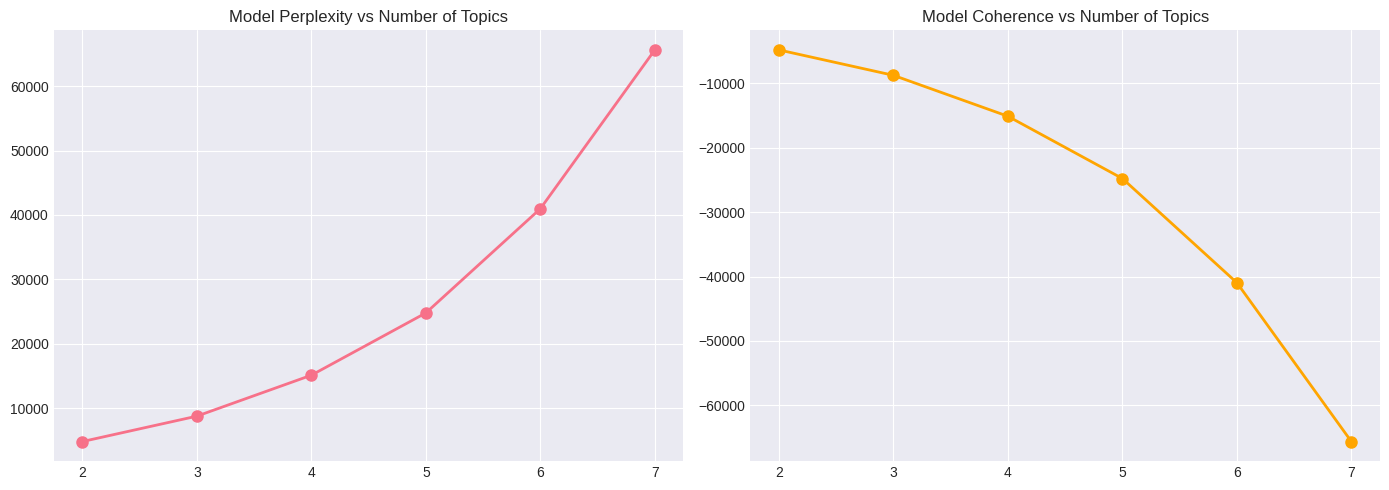

In [8]:
print("\n=== Finding Optimal Number of Topics ===")
coherence_scores = []
perplexity_scores = []
topic_range = range(2, 8) # Range diperkecil menyesuaikan volume data sampel

for num_topics in topic_range:
    lda = LatentDirichletAllocation(n_components=num_topics, random_state=stm.random_state, n_jobs=-1, max_iter=10)
    lda.fit(stm.dtm)
    perplexity = lda.perplexity(stm.dtm)
    perplexity_scores.append(perplexity)
    coherence_scores.append(-perplexity)

# Plotting langsung di dalam notebook
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(topic_range, perplexity_scores, 'o-', linewidth=2, markersize=8)
ax1.set_title('Model Perplexity vs Number of Topics')
ax2.plot(topic_range, coherence_scores, 'o-', linewidth=2, markersize=8, color='orange')
ax2.set_title('Model Coherence vs Number of Topics')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/optimal_topics.png', dpi=300)
plt.show()

In [9]:
# Tentukan jumlah topik akhir berdasarkan grafik di atas (misal: 5)
stm.num_topics = 5

print(f"\n=== Fitting LDA Model ({stm.num_topics} topics) ===")
stm.lda_model = LatentDirichletAllocation(
    n_components=stm.num_topics, random_state=stm.random_state,
    max_iter=20, learning_method='online', n_jobs=-1
)
stm.lda_model.fit(stm.dtm)

# Ekstraksi Kata Kunci per Topik
feature_names = stm.vectorizer.get_feature_names_out()
topics_dict = {}

for topic_idx, topic in enumerate(stm.lda_model.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [feature_names[i] for i in top_indices]
    top_weights = [topic[i] for i in top_indices]

    topic_name = f"Topic {topic_idx + 1}"
    topics_dict[topic_name] = {'words': top_words, 'weights': top_weights}
    print(f"{topic_name}: {', '.join(top_words)}")


=== Fitting LDA Model (5 topics) ===
Topic 1: ensures, single, leadership, cdw, cdws, ability, organization, production, learning, machine
Topic 2: bank, information, risk, company, process, metric, decision, sector, modelling, help
Topic 3: database, business, enterprise, investment, warehousing, firm, logistics, tourist, edw, value
Topic 4: clinical, cube, product, cdw, process, local, using, federal, barrier, service
Topic 5: process, etl, business, management, variable, big, information, maturity, hive, source



=== Generating Topic Word Clouds ===


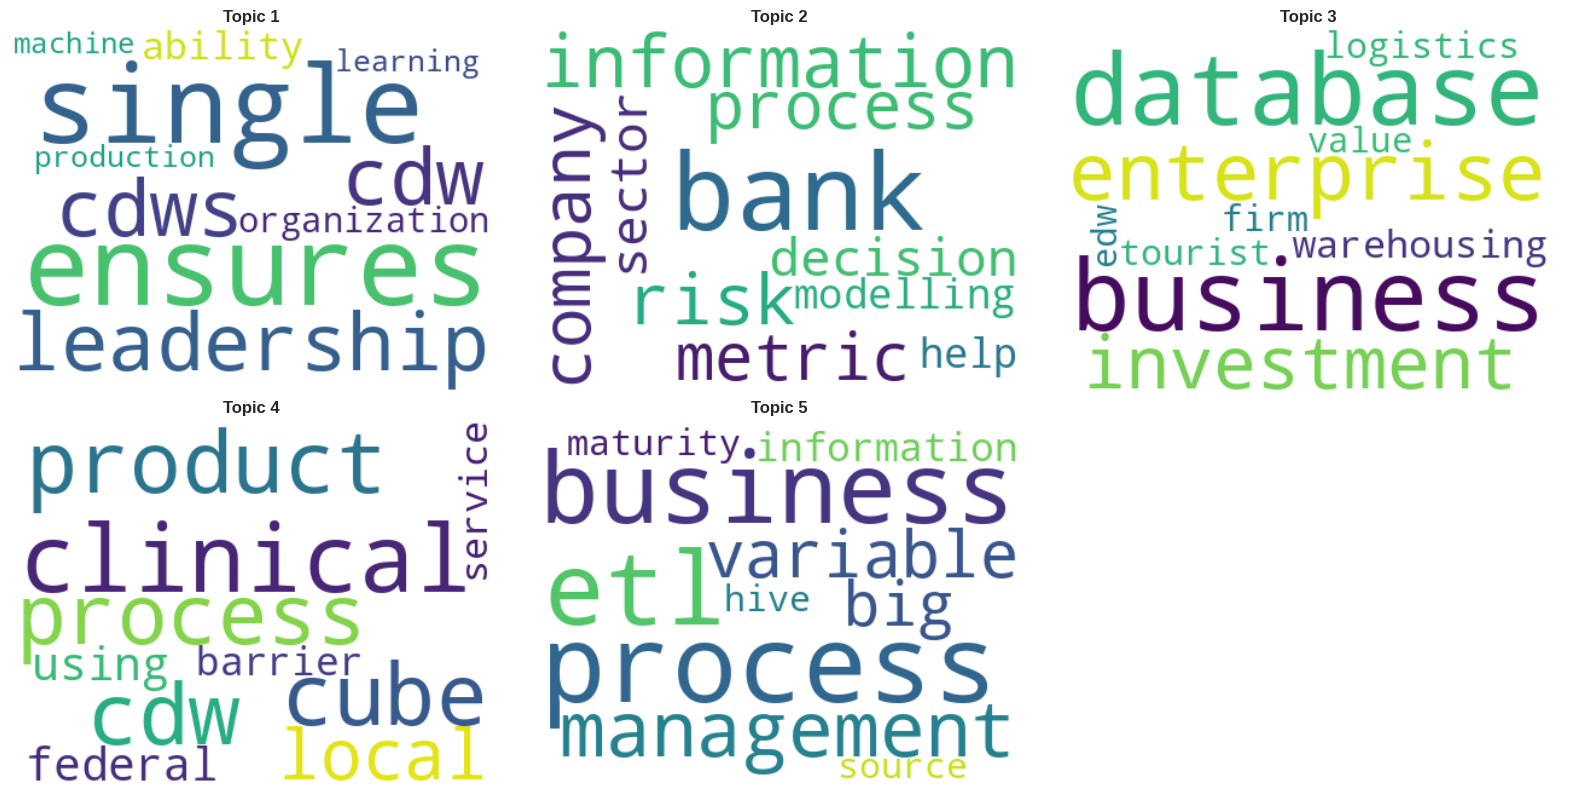

In [10]:
print("\n=== Generating Topic Word Clouds ===")
cols = 3
rows = (stm.num_topics + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, 4*rows))
axes = axes.flatten()

for idx, (topic_name, topic_data) in enumerate(topics_dict.items()):
    word_freq = {w: float(wt) for w, wt in zip(topic_data['words'], topic_data['weights'])}
    wordcloud = WordCloud(width=400, height=300, background_color='white', colormap='viridis').generate_from_frequencies(word_freq)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(topic_name, fontsize=12, fontweight='bold')
    axes[idx].axis('off')

for idx in range(len(topics_dict), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/topic_wordclouds.png', dpi=300)
plt.show()


=== Calculating Topic Distributions & Trends ===


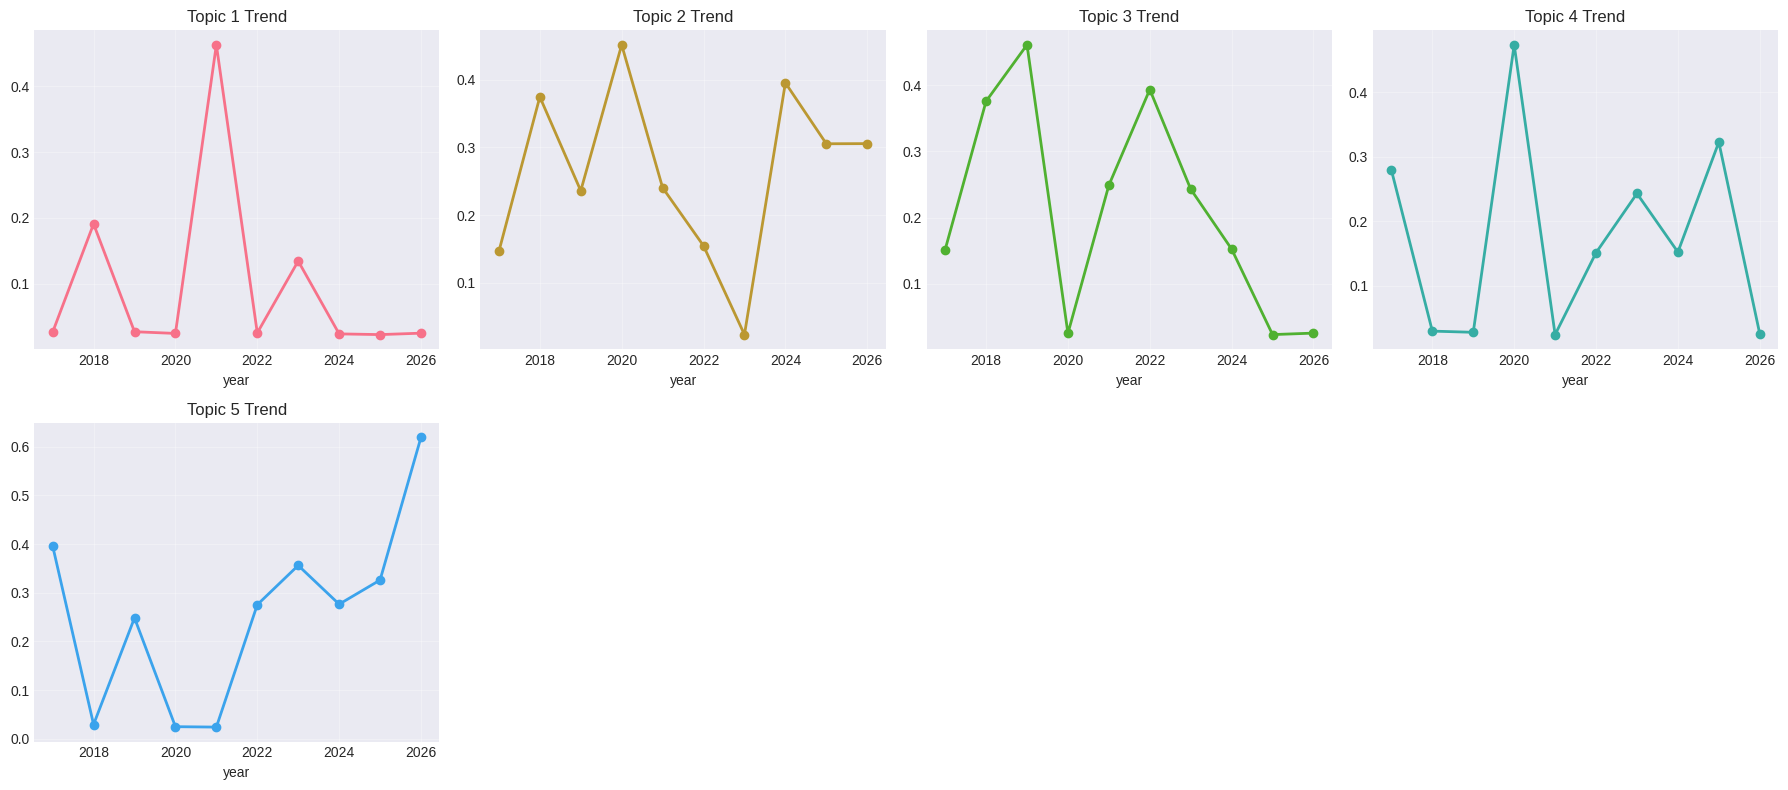

In [11]:
print("\n=== Calculating Topic Distributions & Trends ===")
doc_topic_dist = stm.lda_model.transform(stm.dtm)
doc_topic_df = pd.DataFrame(doc_topic_dist, columns=[f'Topic_{i+1}' for i in range(stm.num_topics)])

# Tren Berdasarkan Tahun
trend_data = pd.concat([stm.documents[['year']], doc_topic_df], axis=1)
yearly_trends = trend_data.groupby('year').mean()

# Plot Tren
fig, axes = plt.subplots((stm.num_topics + 3) // 4, min(stm.num_topics, 4), figsize=(18, 8))
axes = axes.flatten()

for topic_idx in range(stm.num_topics):
    ax = axes[topic_idx]
    topic_col = f'Topic_{topic_idx + 1}'
    yearly_trends[topic_col].plot(ax=ax, marker='o', linewidth=2, color=f'C{topic_idx}')
    ax.set_title(f'Topic {topic_idx + 1} Trend')
    ax.grid(True, alpha=0.3)

for idx in range(stm.num_topics, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/topic_trends.png', dpi=300)
plt.show()


=== Topic Correlations & Network ===


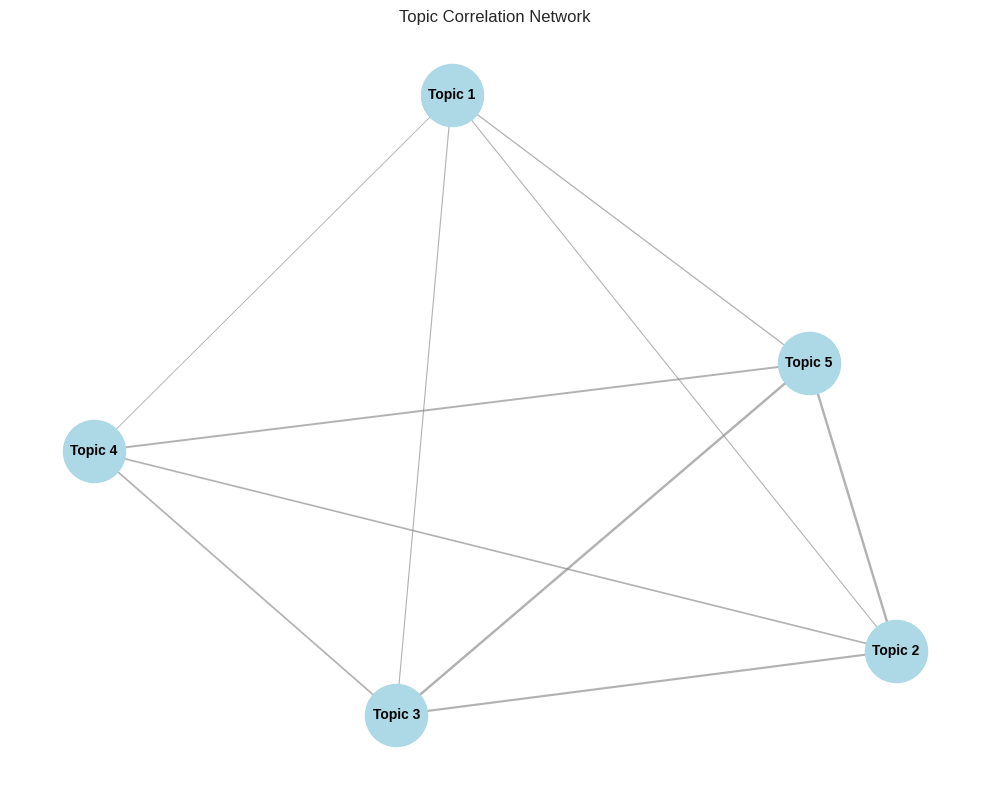

In [12]:
print("\n=== Topic Correlations & Network ===")
topic_cols = [f'Topic_{i+1}' for i in range(stm.num_topics)]
correlation_matrix = doc_topic_df[topic_cols].corr()

# Buat Jaringan (Network)
G = nx.Graph()
threshold = 0.1 # Disesuaikan agar memunculkan relasi pada sampel kecil

for i in range(len(correlation_matrix)):
    for j in range(i+1, len(correlation_matrix)):
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            G.add_edge(f'Topic {i+1}', f'Topic {j+1}', weight=abs(correlation_matrix.iloc[i, j]))

fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.spring_layout(G, k=2, seed=42)
weights = [G[u][v]['weight'] for u, v in G.edges()]

nx.draw_networkx_edges(G, pos, width=[w*5 for w in weights], alpha=0.6, ax=ax, edge_color='gray')
nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold', ax=ax)

ax.set_title('Topic Correlation Network')
ax.axis('off')
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/topic_network.png', dpi=300)
plt.show()

In [13]:
# Ekspor hasil pemetaan dokumen ke topik ke CSV
result_df = pd.concat([stm.documents[['title', 'year', 'journal']], doc_topic_df], axis=1)
result_df.to_csv('/mnt/user-data/outputs/document_topic_results.csv', index=False)

print("=== PROSES SELESAI ===")
print("Seluruh grafik dan berkas CSV berhasil disimpan di direktori `/mnt/user-data/outputs/`")
result_df.head()

=== PROSES SELESAI ===
Seluruh grafik dan berkas CSV berhasil disimpan di direktori `/mnt/user-data/outputs/`


,title,year,journal,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5
0,Design and Implementation Data Warehouse in In...,2019.0,Journal of Physics:\nConference Series,0.032800,0.867618,0.033223,0.032959,0.033401
1,Good practices for clinical data warehouse imp...,2023.0,PLOS Digital Health,0.911083,0.022139,0.022138,0.022321,0.022320
2,Enterprise Data warehouse and Business Intelli...,2018.0,International Conference on Theory and Practic...,0.026541,0.026674,0.893330,0.026631,0.026823
3,On construction of a big data warehouse access...,2019.0,Journal of Parallel and Distributed Computing,0.023264,0.023457,0.023388,0.023345,0.906545
4,Building an Effective Data Warehousing for Fin...,2017.0,Automatic Control and Information Sciences,0.022096,0.022677,0.022419,0.910394,0.022414
